In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# dataset Load

data = pd.read_csv(r"C:\Users\hp\Downloads\UNSW_NB15_training-set.csv")

In [3]:
data

,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.000011,udp,-,INT,2,0,496,0,90909.090200,...,1,2,0,0,0,1,2,0,Normal,0
1,2,0.000008,udp,-,INT,2,0,1762,0,125000.000300,...,1,2,0,0,0,1,2,0,Normal,0
2,3,0.000005,udp,-,INT,2,0,1068,0,200000.005100,...,1,3,0,0,0,1,3,0,Normal,0
3,4,0.000006,udp,-,INT,2,0,900,0,166666.660800,...,1,3,0,0,0,2,3,0,Normal,0
4,5,0.000010,udp,-,INT,2,0,2126,0,100000.002500,...,1,3,0,0,0,2,3,0,Normal,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
82327,82328,0.000005,udp,-,INT,2,0,104,0,200000.005100,...,1,2,0,0,0,2,1,0,Normal,0
82328,82329,1.106101,tcp,-,FIN,20,8,18062,354,24.410067,...,1,1,0,0,0,3,2,0,Normal,0
82329,82330,0.000000,arp,-,INT,1,0,46,0,0.000000,...,1,1,0,0,0,1,1,1,Normal,0
82330,82331,0.000000,arp,-,INT,1,0,46,0,0.000000,...,1,1,0,0,0,1,1,1,Normal,0


In [4]:
data.head()

,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.000011,udp,-,INT,2,0,496,0,90909.0902,...,1,2,0,0,0,1,2,0,Normal,0
1,2,0.000008,udp,-,INT,2,0,1762,0,125000.0003,...,1,2,0,0,0,1,2,0,Normal,0
2,3,0.000005,udp,-,INT,2,0,1068,0,200000.0051,...,1,3,0,0,0,1,3,0,Normal,0
3,4,0.000006,udp,-,INT,2,0,900,0,166666.6608,...,1,3,0,0,0,2,3,0,Normal,0
4,5,0.000010,udp,-,INT,2,0,2126,0,100000.0025,...,1,3,0,0,0,2,3,0,Normal,0


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 82332 entries, 0 to 82331
Data columns (total 45 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 82332 non-null  int64  
 1   dur                82332 non-null  float64
 2   proto              82332 non-null  object 
 3   service            82332 non-null  object 
 4   state              82332 non-null  object 
 5   spkts              82332 non-null  int64  
 6   dpkts              82332 non-null  int64  
 7   sbytes             82332 non-null  int64  
 8   dbytes             82332 non-null  int64  
 9   rate               82332 non-null  float64
 10  sttl               82332 non-null  int64  
 11  dttl               82332 non-null  int64  
 12  sload              82332 non-null  float64
 13  dload              82332 non-null  float64
 14  sloss              82332 non-null  int64  
 15  dloss              82332 non-null  int64  
 16  sinpkt             823

In [6]:
data.isnull().sum()

id                   0
dur                  0
proto                0
service              0
state                0
spkts                0
dpkts                0
sbytes               0
dbytes               0
rate                 0
sttl                 0
dttl                 0
sload                0
dload                0
sloss                0
dloss                0
sinpkt               0
dinpkt               0
sjit                 0
djit                 0
swin                 0
stcpb                0
dtcpb                0
dwin                 0
tcprtt               0
synack               0
ackdat               0
smean                0
dmean                0
trans_depth          0
response_body_len    0
ct_srv_src           0
ct_state_ttl         0
ct_dst_ltm           0
ct_src_dport_ltm     0
ct_dst_sport_ltm     0
ct_dst_src_ltm       0
is_ftp_login         0
ct_ftp_cmd           0
ct_flw_http_mthd     0
ct_src_ltm           0
ct_srv_dst           0
is_sm_ips_ports      0
attack_cat 

In [7]:
data.describe()

,id,dur,spkts,dpkts,sbytes,dbytes,rate,sttl,dttl,sload,...,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,label
count,82332.000000,82332.000000,82332.000000,82332.000000,8.233200e+04,8.233200e+04,8.233200e+04,82332.000000,82332.000000,8.233200e+04,...,82332.000000,82332.000000,82332.000000,82332.000000,82332.000000,82332.000000,82332.000000,82332.000000,82332.000000,82332.000000
mean,41166.500000,1.006756,18.666472,17.545936,7.993908e+03,1.323379e+04,8.241089e+04,180.967667,95.713003,6.454902e+07,...,4.928898,3.663011,7.456360,0.008284,0.008381,0.129743,6.468360,9.164262,0.011126,0.550600
std,23767.345519,4.710444,133.916353,115.574086,1.716423e+05,1.514715e+05,1.486204e+05,101.513358,116.667722,1.798618e+08,...,8.389545,5.915386,11.415191,0.091171,0.092485,0.638683,8.543927,11.121413,0.104891,0.497436
min,1.000000,0.000000,1.000000,0.000000,2.400000e+01,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000e+00,...,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000
25%,20583.750000,0.000008,2.000000,0.000000,1.140000e+02,0.000000e+00,2.860611e+01,62.000000,0.000000,1.120247e+04,...,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,2.000000,0.000000,0.000000
50%,41166.500000,0.014138,6.000000,2.000000,5.340000e+02,1.780000e+02,2.650177e+03,254.000000,29.000000,5.770032e+05,...,1.000000,1.000000,3.000000,0.000000,0.000000,0.000000,3.000000,5.000000,0.000000,1.000000
75%,61749.250000,0.719360,12.000000,10.000000,1.280000e+03,9.560000e+02,1.111111e+05,254.000000,252.000000,6.514286e+07,...,4.000000,3.000000,6.000000,0.000000,0.000000,0.000000,7.000000,11.000000,0.000000,1.000000
max,82332.000000,59.999989,10646.000000,11018.000000,1.435577e+07,1.465753e+07,1.000000e+06,255.000000,253.000000,5.268000e+09,...,59.000000,38.000000,63.000000,2.000000,2.000000,16.000000,60.000000,62.000000,1.000000,1.000000


In [8]:
# Separate columns
num_cols = data.select_dtypes(include=['int64', 'float64']).columns
cat_cols = data.select_dtypes(include=['object']).columns

print("Numerical Columns:", len(num_cols))
print(num_cols)

print("\nCategorical Columns:", len(cat_cols))
print(cat_cols)

Numerical Columns: 41
Index(['id', 'dur', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl',
       'dttl', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit',
       'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat',
       'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_srv_src',
       'ct_state_ttl', 'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm',
       'ct_dst_src_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd',
       'ct_src_ltm', 'ct_srv_dst', 'is_sm_ips_ports', 'label'],
      dtype='object')

Categorical Columns: 4
Index(['proto', 'service', 'state', 'attack_cat'], dtype='object')


In [9]:
summary = pd.DataFrame({
    'Feature': data.columns,
    'Data Type': data.dtypes,
    'Missing Values': data.isnull().sum(),
    'Unique Values': data.nunique()
})

summary

,Feature,Data Type,Missing Values,Unique Values
id,id,int64,0,82332
dur,dur,float64,0,39888
proto,proto,object,0,131
service,service,object,0,13
state,state,object,0,7
spkts,spkts,int64,0,420
dpkts,dpkts,int64,0,436
sbytes,sbytes,int64,0,4489
dbytes,dbytes,int64,0,4034
rate,rate,float64,0,40616


# EDA

Class Distribution

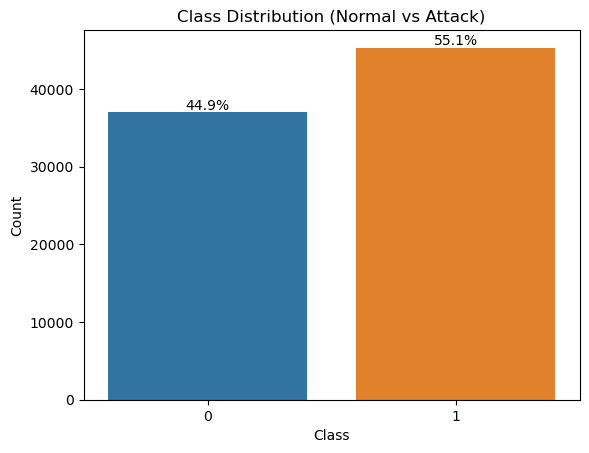

In [10]:
ax = sns.countplot(x='label', data=data)

total = len(data)
for p in ax.patches:
    percentage = f'{100 * p.get_height()/total:.1f}%'
    ax.annotate(percentage, (p.get_x()+p.get_width()/2, p.get_height()),
                ha='center', va='bottom')

plt.title("Class Distribution (Normal vs Attack)")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

Attack Category Distribution

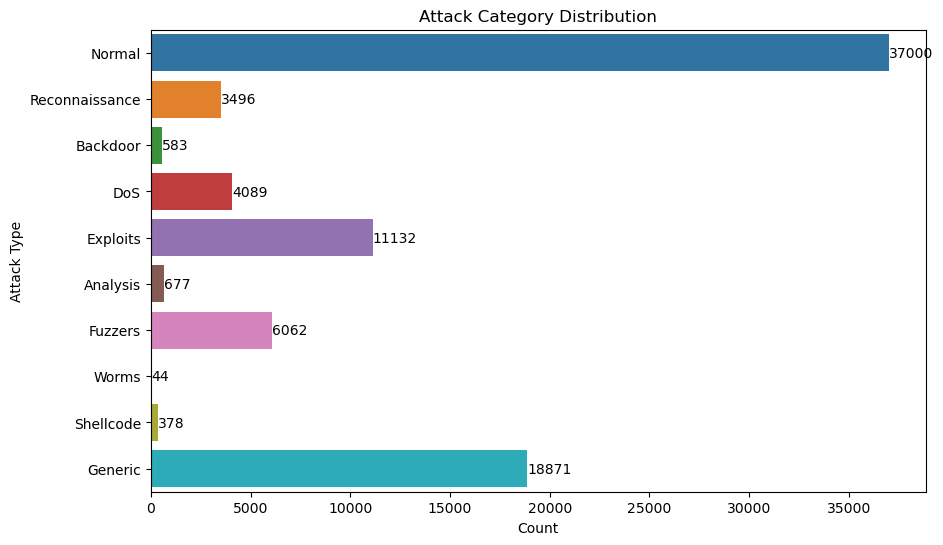

In [11]:
plt.figure(figsize=(10,6))
ax = sns.countplot(y='attack_cat', data=data)

for p in ax.patches:
    ax.annotate(int(p.get_width()), 
                (p.get_width(), p.get_y()+0.5))

plt.title("Attack Category Distribution")
plt.xlabel("Count")
plt.ylabel("Attack Type")
plt.show()

Protocol Distribution

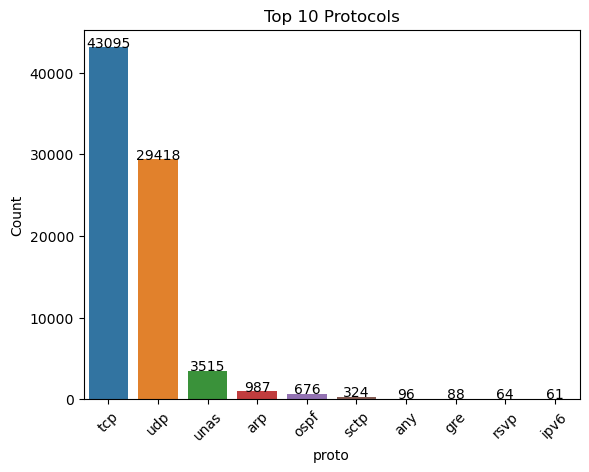

In [12]:
top_proto = data['proto'].value_counts().head(10)

ax = sns.barplot(x=top_proto.index, y=top_proto.values)

for i, v in enumerate(top_proto.values):
    ax.text(i, v, str(v), ha='center')

plt.xticks(rotation=45)
plt.title("Top 10 Protocols")
plt.ylabel("Count")
plt.show()

Duration Distribution

C:\ProgramData\anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


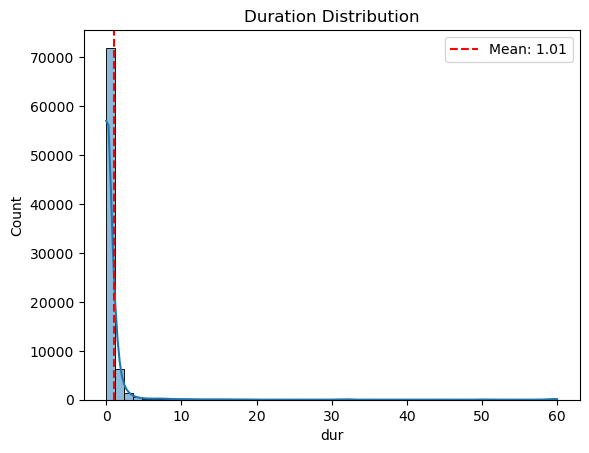

In [13]:
sns.histplot(data['dur'], bins=50, kde=True)

mean_val = data['dur'].mean()
plt.axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.2f}')

plt.legend()
plt.title("Duration Distribution")
plt.show()

Source Bytes Distribution

C:\ProgramData\anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


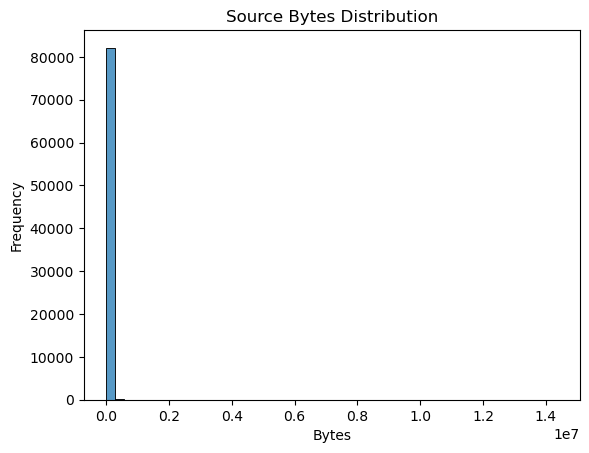

In [14]:
sns.histplot(data['sbytes'], bins=50)

plt.title("Source Bytes Distribution")
plt.xlabel("Bytes")
plt.ylabel("Frequency")
plt.show()

Boxplot with Median Labels

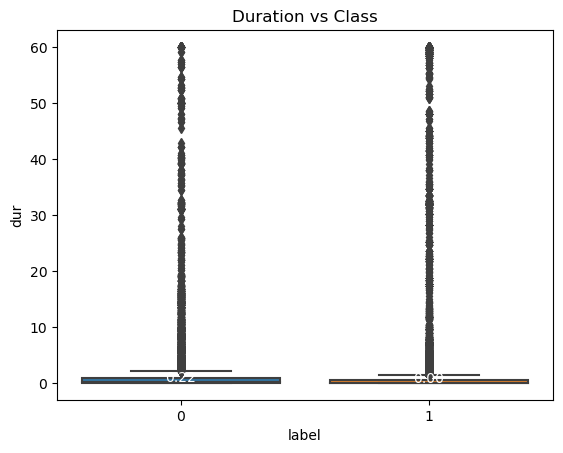

In [15]:
ax = sns.boxplot(x='label', y='dur', data=data)

medians = data.groupby(['label'])['dur'].median()

for i, median in enumerate(medians):
    ax.text(i, median, f'{median:.2f}', ha='center', color='white')

plt.title("Duration vs Class")
plt.show()

Correlation Heatmap

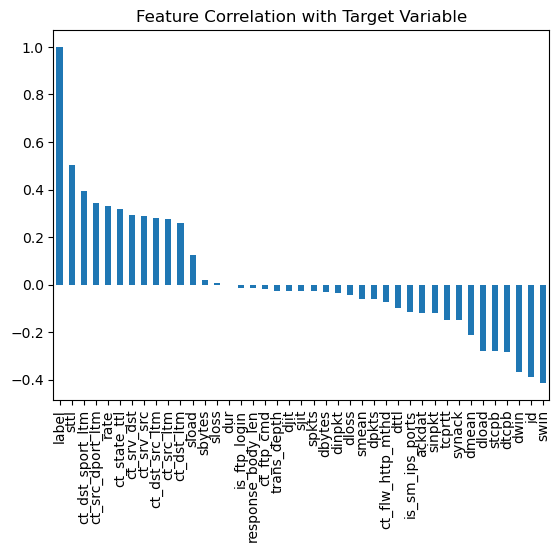

In [16]:
numeric_df = data.select_dtypes(include=['int64', 'float64'])

corr_target = numeric_df.corr()['label'].sort_values(ascending=False)

corr_target.plot(kind='bar')

plt.title("Feature Correlation with Target Variable")
plt.show()

Pairplot

C:\ProgramData\anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\ProgramData\anaconda3\lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\ProgramData\anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\ProgramData\anaconda3\lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length

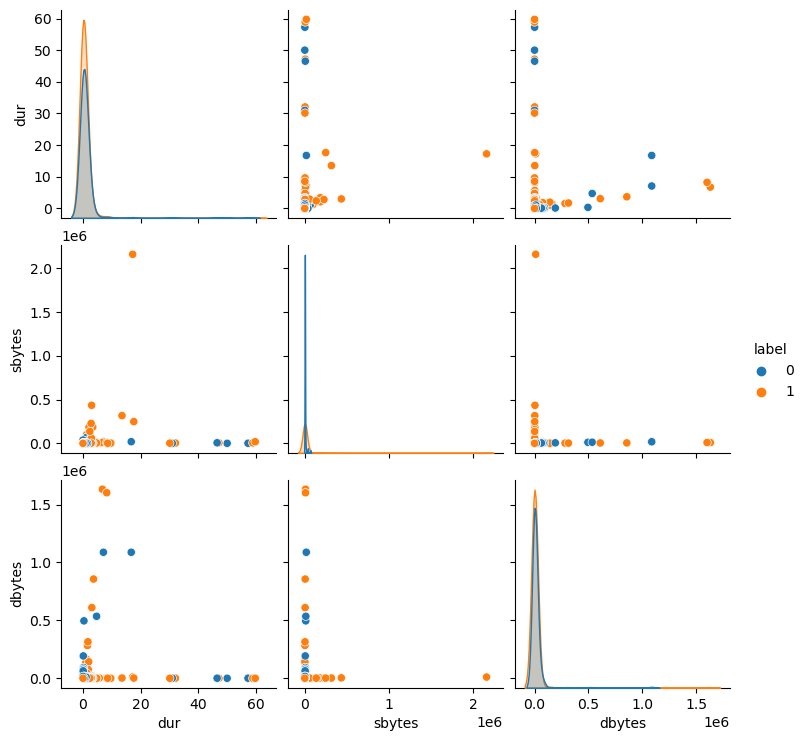

In [17]:
sample_df = data.sample(1000)
sns.pairplot(sample_df[['dur','sbytes','dbytes','label']], hue='label')
plt.show()

Feature Distribution by Class

C:\ProgramData\anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\ProgramData\anaconda3\lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


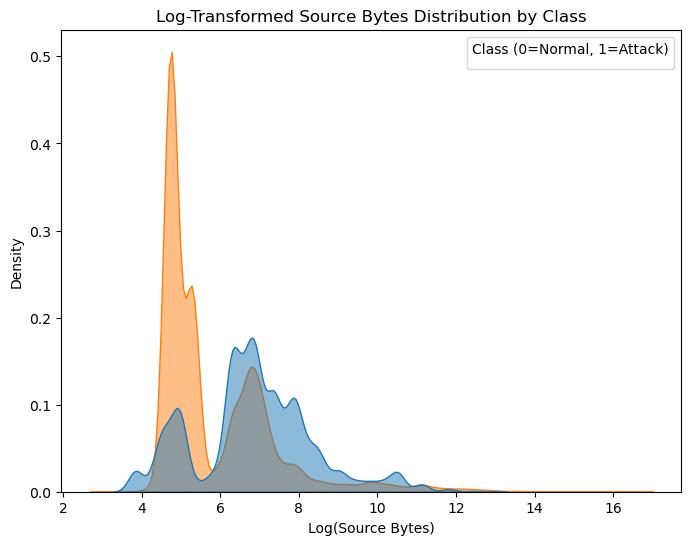

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Create log-transformed feature
data['log_sbytes'] = np.log1p(data['sbytes'])

plt.figure(figsize=(8,6))

sns.kdeplot(data=data, x='log_sbytes', hue='label', fill=True, alpha=0.5)

plt.title("Log-Transformed Source Bytes Distribution by Class")
plt.xlabel("Log(Source Bytes)")
plt.ylabel("Density")
plt.legend(title="Class (0=Normal, 1=Attack)")

plt.show()

Attack Category vs Duration

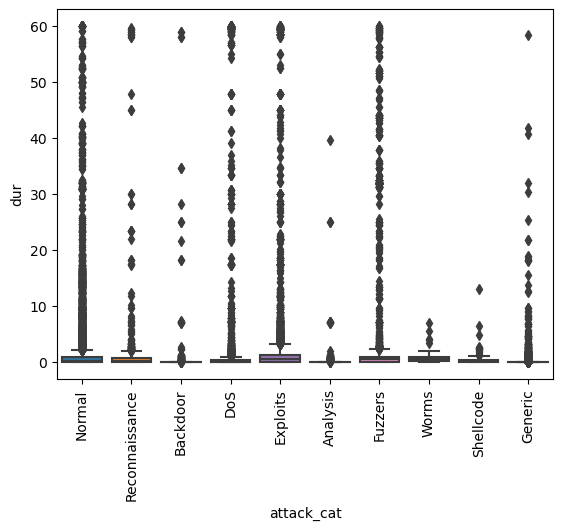

In [19]:
sns.boxplot(x='attack_cat', y='dur', data=data)
plt.xticks(rotation=90)
plt.show()

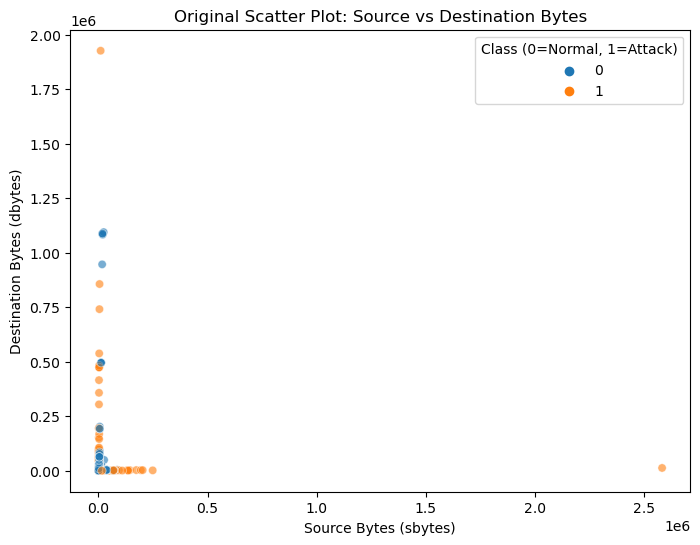

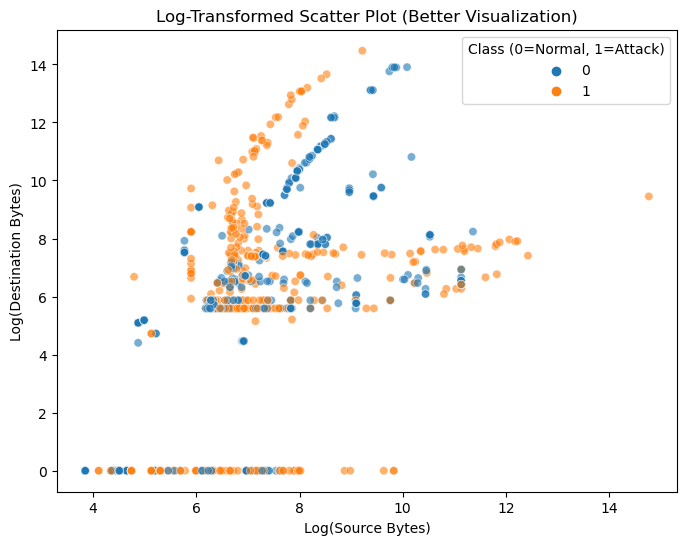

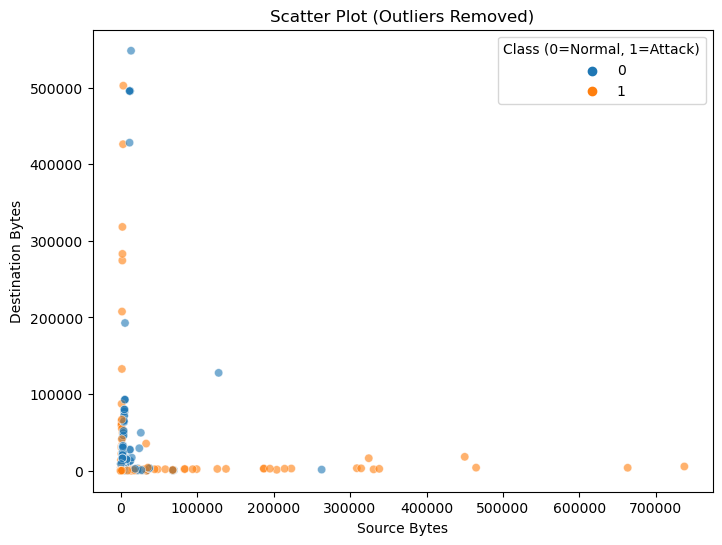

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Take sample for better visualization
data_sample = data.sample(2000, random_state=42)


# 1. ORIGINAL SCATTER PLOT

plt.figure(figsize=(8,6))
sns.scatterplot(x='sbytes', y='dbytes', hue='label', data=data_sample, alpha=0.6)

plt.title("Original Scatter Plot: Source vs Destination Bytes")
plt.xlabel("Source Bytes (sbytes)")
plt.ylabel("Destination Bytes (dbytes)")
plt.legend(title="Class (0=Normal, 1=Attack)")
plt.show()



# 2. LOG-TRANSFORMED PLOT (BEST)

data_sample['log_sbytes'] = np.log1p(data_sample['sbytes'])
data_sample['log_dbytes'] = np.log1p(data_sample['dbytes'])

plt.figure(figsize=(8,6))
sns.scatterplot(x='log_sbytes', y='log_dbytes', hue='label', data=data_sample, alpha=0.6)

plt.title("Log-Transformed Scatter Plot (Better Visualization)")
plt.xlabel("Log(Source Bytes)")
plt.ylabel("Log(Destination Bytes)")
plt.legend(title="Class (0=Normal, 1=Attack)")
plt.show()



# 3. OUTLIER REMOVED PLOT

data_filtered = data[(data['sbytes'] < 1e6) & (data['dbytes'] < 1e6)]

plt.figure(figsize=(8,6))
sns.scatterplot(x='sbytes', y='dbytes', hue='label', 
                data=data_filtered.sample(2000, random_state=42), alpha=0.6)

plt.title("Scatter Plot (Outliers Removed)")
plt.xlabel("Source Bytes")
plt.ylabel("Destination Bytes")
plt.legend(title="Class (0=Normal, 1=Attack)")
plt.show()

# Model Implemantation

In [21]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc

from imblearn.over_sampling import SMOTE



In [22]:
# Encode categorical features

le = LabelEncoder()

for col in data.select_dtypes(include='object').columns:
    data[col] = le.fit_transform(data[col])

In [23]:
# Define Features & Target
X = data.drop(['label', 'attack_cat', 'id'], axis=1)
y = data['label']

In [24]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)

In [25]:
# Handle Imbalance

smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

In [26]:
# Feature Scaling

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [27]:
# Evaluation Function
def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)

    print(f"\n{name} Performance")
    print("-" * 30)
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1 Score:", f1_score(y_test, y_pred))

    print("\nClassification Report:\n", classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt='d')
    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

MODEL 1 — Logistic Regression


Logistic Regression Performance
------------------------------
Accuracy: 0.8997165991902834
Precision: 0.9126660235957558
Recall: 0.9044117647058824
F1 Score: 0.9085201462495845

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.89      0.89     11100
           1       0.91      0.90      0.91     13600

    accuracy                           0.90     24700
   macro avg       0.90      0.90      0.90     24700
weighted avg       0.90      0.90      0.90     24700



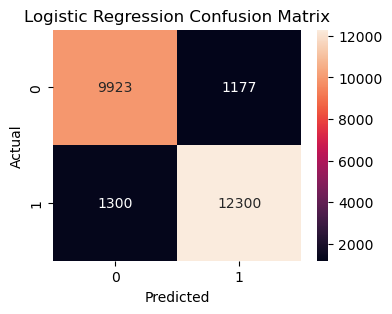

In [28]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

evaluate_model("Logistic Regression", lr, X_test, y_test)

MODEL 2 — Random Forest


Random Forest (Baseline) Performance
------------------------------
Accuracy: 0.9759109311740891
Precision: 0.984501900007451
Recall: 0.9715441176470588
F1 Score: 0.9779800895599718

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.98      0.97     11100
           1       0.98      0.97      0.98     13600

    accuracy                           0.98     24700
   macro avg       0.98      0.98      0.98     24700
weighted avg       0.98      0.98      0.98     24700



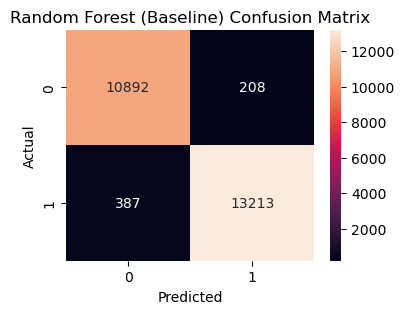

In [29]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

evaluate_model("Random Forest (Baseline)", rf, X_test, y_test)

MODEL 3 — Support Vector Machine


SVM Performance
------------------------------
Accuracy: 0.9380161943319838
Precision: 0.9655172413793104
Recall: 0.9202941176470588
F1 Score: 0.9423634378646991

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.96      0.93     11100
           1       0.97      0.92      0.94     13600

    accuracy                           0.94     24700
   macro avg       0.94      0.94      0.94     24700
weighted avg       0.94      0.94      0.94     24700



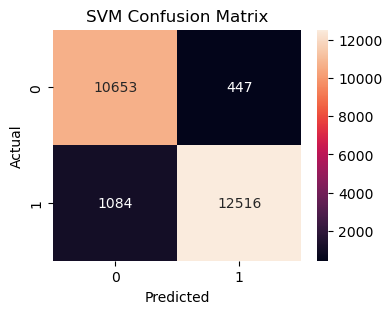

In [30]:
svm = SVC(probability=True)
svm.fit(X_train, y_train)

evaluate_model("SVM", svm, X_test, y_test)

Model Comparison Table

In [31]:
results = []

models = {
    "Logistic Regression": lr,
    "Random Forest": rf,
    "SVM": svm
}

for name, model in models.items():
    y_pred = model.predict(X_test)

    results.append([
        name,
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred)
    ])

results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "Precision", "Recall", "F1 Score"])
results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.899717,0.912666,0.904412,0.908520
1,Random Forest,0.975911,0.984502,0.971544,0.977980
2,SVM,0.938016,0.965517,0.920294,0.942363


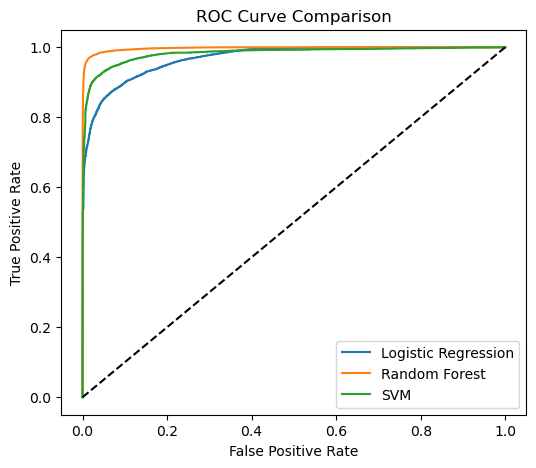

In [32]:
# ROC Curve

plt.figure(figsize=(6,5))

for name, model in models.items():
    y_prob = model.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=name)

plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

Feature Importance

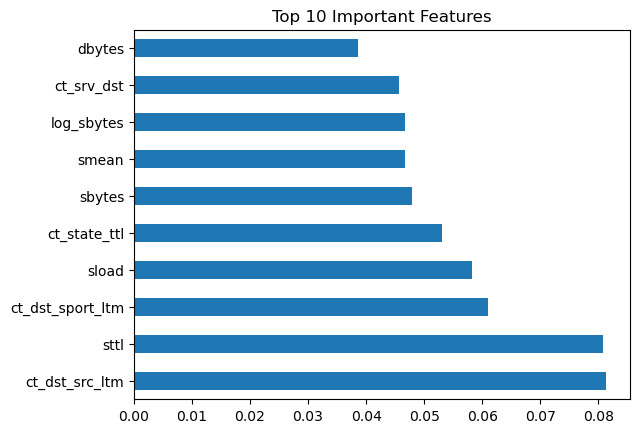

In [33]:
importances = rf.feature_importances_
features = pd.Series(importances, index=X.columns)

features.nlargest(10).plot(kind='barh')
plt.title("Top 10 Important Features")
plt.show()

Hyperparameter Tuning

In [34]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20]
}

grid = GridSearchCV(RandomForestClassifier(), param_grid, cv=3)
grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

Best Parameters: {'max_depth': 20, 'n_estimators': 200}



Random Forest (Tuned) Performance
------------------------------
Accuracy: 0.9765182186234818
Precision: 0.985820895522388
Recall: 0.9713235294117647
F1 Score: 0.9785185185185186

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.98      0.97     11100
           1       0.99      0.97      0.98     13600

    accuracy                           0.98     24700
   macro avg       0.98      0.98      0.98     24700
weighted avg       0.98      0.98      0.98     24700



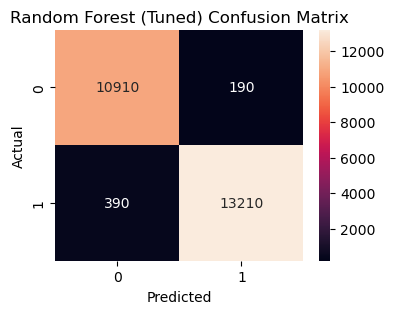

In [35]:
final_rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    random_state=42
)

final_rf.fit(X_train, y_train)

evaluate_model("Random Forest (Tuned)", final_rf, X_test, y_test)